In [ ]:
# 1. Instalar bibliotecas de explicabilidade (não vêm por padrão no Colab)
!pip install shap -q

# 2. Importar o essencial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Configuração visual
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
# Descarregar um dataset real de risco de crédito
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['checkin_acc', 'duration', 'credit_history', 'purpose', 'amount',
           'saving_acc', 'present_emp_since', 'inst_rate', 'personal_status',
           'other_debtors', 'residing_since', 'property', 'age',
           'inst_plans', 'housing', 'num_credits', 'job', 'status', 'telephone', 'foreign_worker', 'target']

df = pd.read_csv(url, sep=' ', names=columns)

# Ajustar o target: 1 = Bom pagador, 2 = Mau pagador -> Vamos mudar para 0 e 1
df['target'] = df['target'].map({1: 0, 2: 1})
df.head()

,checkin_acc,duration,credit_history,purpose,amount,saving_acc,present_emp_since,inst_rate,personal_status,other_debtors,...,property,age,inst_plans,housing,num_credits,job,status,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [ ]:
# Exemplo de criação de variável estratégica
df['age_emp_ratio'] = df['age'] / (df['residing_since'] + 1)
print("Nova métrica de estabilidade criada!")

Nova métrica de estabilidade criada!


/tmp/ipykernel_293/3809668376.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='amount', palette='viridis')


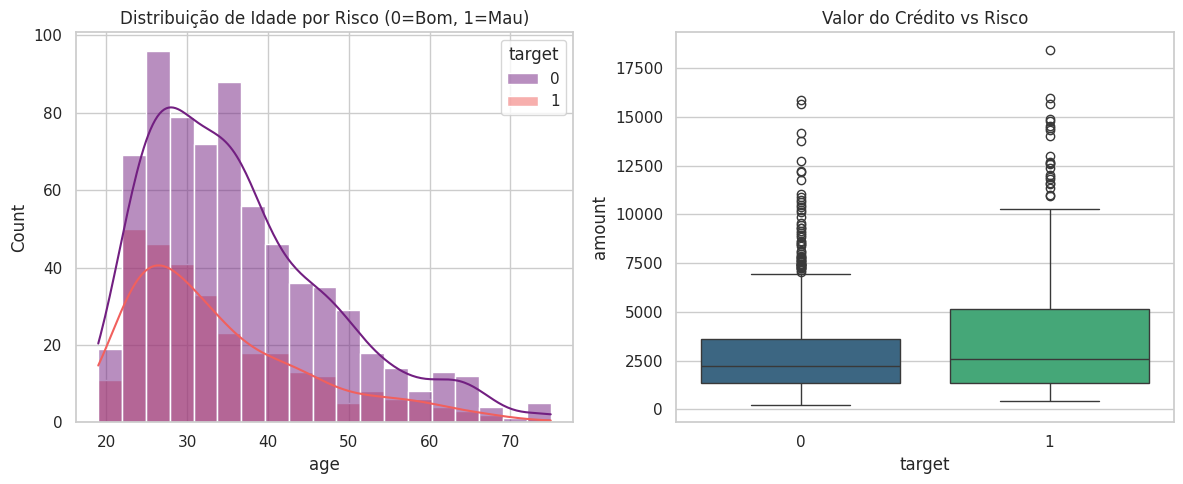

In [4]:
# 1. Distribuição de Idade por Risco
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='target', kde=True, palette='magma')
plt.title('Distribuição de Idade por Risco (0=Bom, 1=Mau)')

# 2. Relação entre Valor do Crédito e Risco
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='target', y='amount', palette='viridis')
plt.title('Valor do Crédito vs Risco')

plt.tight_layout()
plt.show()

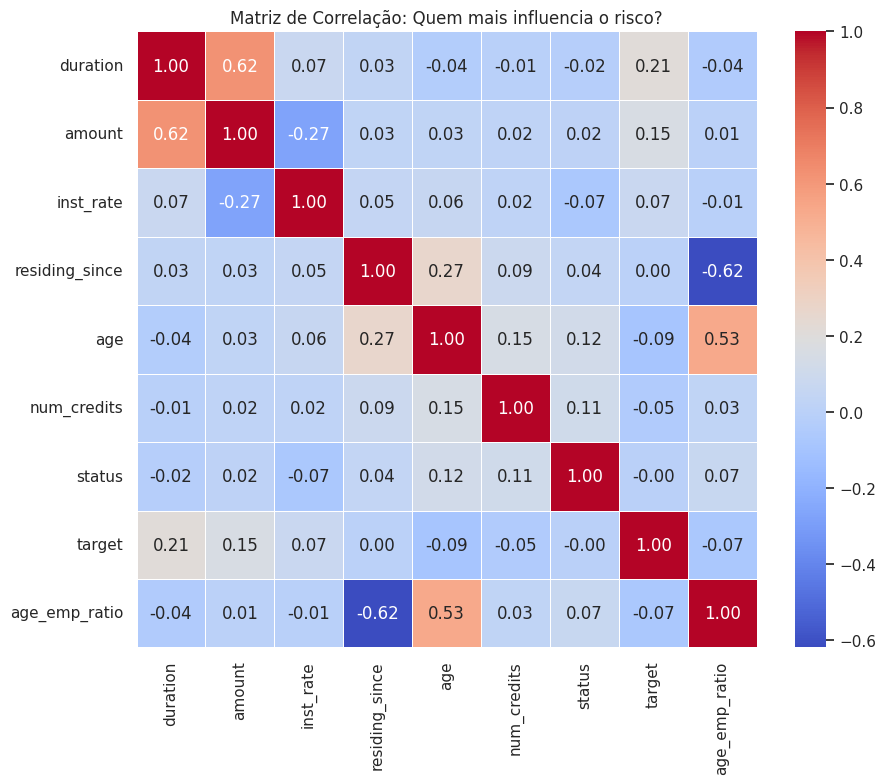

In [5]:
# Criando uma matriz de correlação para as variáveis numéricas
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação: Quem mais influencia o risco?')
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

# Criando uma cópia para não sujar o dataframe original
df_encoded = df.copy()

# Identificando colunas que são texto (object)
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

print("Sucesso! Todas as categorias foram transformadas em números.")
df_encoded.head()

Sucesso! Todas as categorias foram transformadas em números.


,checkin_acc,duration,credit_history,purpose,amount,saving_acc,present_emp_since,inst_rate,personal_status,other_debtors,...,age,inst_plans,housing,num_credits,job,status,telephone,foreign_worker,target,age_emp_ratio
0,0,6,4,4,1169,4,4,4,2,0,...,67,2,1,2,2,1,1,0,0,13.400000
1,1,48,2,4,5951,0,2,2,1,0,...,22,2,1,1,2,1,0,0,1,7.333333
2,3,12,4,7,2096,0,3,2,2,0,...,49,2,1,1,1,2,0,0,0,12.250000
3,0,42,2,3,7882,0,3,2,2,2,...,45,2,2,1,2,2,0,0,0,9.000000
4,0,24,3,0,4870,0,2,3,2,0,...,53,2,2,2,2,2,0,0,1,10.600000


In [7]:
from sklearn.model_selection import train_test_split

# Separando o que é característica (X) do que é o objetivo (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Dividindo: 70% para a IA aprender e 30% para provar que ela funciona
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados prontos! Temos {X_train.shape[0]} amostras para treino e {X_test.shape[0]} para teste.")

Dados prontos! Temos 700 amostras para treino e 300 para teste.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciar o modelo (usaremos 100 árvores para começar)
modelo_credito = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Treinar a IA com os dados de treino
modelo_credito.fit(X_train, y_train)

# 3. Fazer previsões com os dados que ela nunca viu (X_test)
previsoes = modelo_credito.predict(X_test)

print("IA Treinada com Sucesso! Gerando relatório de performance...")

IA Treinada com Sucesso! Gerando relatório de performance...



--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       209
           1       0.73      0.35      0.47        91

    accuracy                           0.76       300
   macro avg       0.75      0.65      0.66       300
weighted avg       0.76      0.76      0.73       300



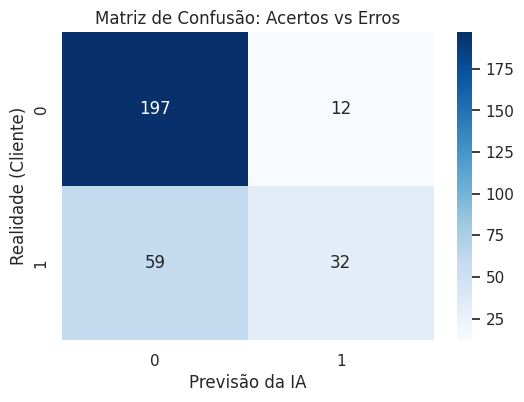

In [9]:
# Verificando a performance
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, previsoes))

# Criando uma matriz de confusão visual
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, previsoes), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão da IA')
plt.ylabel('Realidade (Cliente)')
plt.title('Matriz de Confusão: Acertos vs Erros')
plt.show()

<Figure size 1000x600 with 0 Axes>

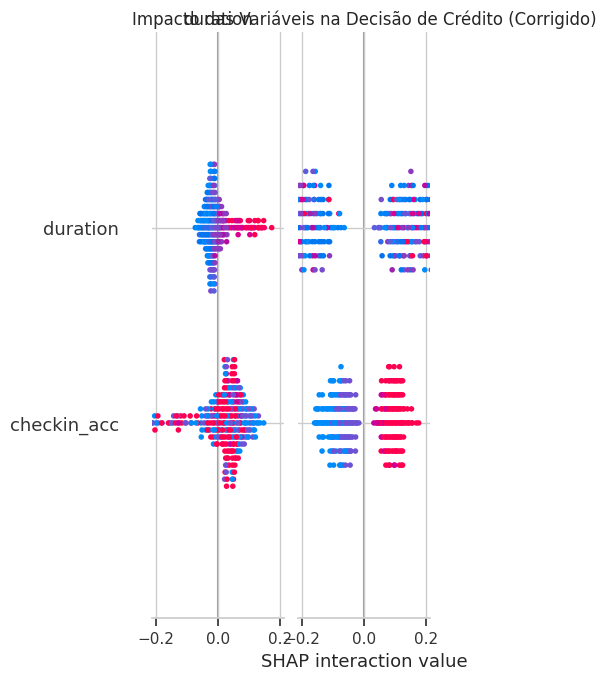

In [11]:
import shap

# 1. Criar o explicador de forma mais compatível
explainer = shap.TreeExplainer(modelo_credito)

# Calculando os valores SHAP
# Note que pegamos apenas os valores para a classe 1 (risco)
shap_values = explainer.shap_values(X_test)

# Se o shap_values vier como uma lista (comum no RandomForest),
# pegamos o índice [1]. Se não, usamos direto.
if isinstance(shap_values, list):
    val_to_plot = shap_values[1]
else:
    val_to_plot = shap_values

# 2. Gerar o gráfico corrigido
plt.figure(figsize=(10,6))
shap.summary_plot(val_to_plot, X_test, show=False)
plt.title("Impacto das Variáveis na Decisão de Crédito (Corrigido)")
plt.show()


In [12]:
import joblib

# Salvando o modelo para usar depois no VS Code ou em um site
joblib.dump(modelo_credito, 'modelo_credito_final.pkl')
joblib.dump(le, 'encoder_final.pkl')

print("Modelo e Encoder salvos com sucesso! Agora você pode baixá-los do Colab.")

Modelo e Encoder salvos com sucesso! Agora você pode baixá-los do Colab.
